<img src=".\assets\on_black.png" alt="netective logo" style="width:18%;">

Compare networks based on their structure and performance statistics.
<br><br>
## Python Module Tutorial

Explore the main features of the Python module for network comparison.

- For a tutorial on the command-line interface, refer to [this link]().
- Access the web service for small jobs [here]().

---

The module consists of two submodules: `structure` and `stats`, each with module-level functions for convenient usage.

In this guide, we'll cover the following topics:

1. **Module-level functions** 📦
2. **Submodule `structure`** 🕸️📐
   Useful for comparing networks with different node IDs.

3. **Submodule `stats`** 📊
   Requires networks to share node IDs. Useful for comparing inferred networks against a gold standard.

<br>

Make sure to have netective installed:

In [ ]:
# %pip install netective

<br>

### Module-level functions 📦

The module-level functions empower users, even those with basic Python proficiency, to seamlessly employ netective to characterize network structure, compare networks, and assess inference performance.

In [ ]:
# Third-party imports
import networkx as nx
from scipy.stats import spearmanr

#### characterize network structure

In [ ]:
from netective import characterize_network

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.7, directed=True)

# Characterize the network is as simple as calling the function with the network and an identifier as arguments
characterize_network(G, "my_network")

Networks may have different size. Use the norm parameter to get normalized values.

In [ ]:
# norm parameter allows you to normalize data using different approaches depending on the nature of the networks analyzed
# default is None for no normalization, uses raw data
# norm = "network" normalize the network by the network size, its default value is None

characterize_network(G, "my_network", norm="network")

In [ ]:
# norm = "biological" normalize the network by the number of regulators

characterize_network(G, "my_network", norm="biological")

Netective v1.0 uses a total of 28 network properties for characterization and comparison:

`Node-Level Properties`
- In-Degree (InDegre)
- Out-Degree (OutDegre)
- Locality Index (LocalityIndex)
- Subgraph Centrality (SubgraphCentrality)
- Average Degree of Nearest Neighbors using out-out degree (AverageOutDegreeNearestNeighbors)
- Average Degree of Nearest Neighbors using undirected network (AverageDegreeNearestNeighbors)
- Clustering Coefficient (ClusteringCoefficient)
- Rich Club Coefficient (RichClub)
- Betweenness Centrality (BetweennessCentrality)
- Eccentricity (Eccentricity)

`Network-Level Properties`
- Entropy of Degree Distribution (EntropyPKout)
- Gini Index (GiniIndex)
- Max In-Degree (MaxInDegree)
- Max Out-Degree (MaxOutDegree)
- Regulators (Regulators)
- Self-Regulations (SelfRegulations)
- Density (Density)
- Complex Feed-Forward Circuits (ComplexFeedForwardCircuits)
- 3-Feedback Loops (FeedbakcLoops_3)
- Average Clustering Coefficient (AverageClusteringCoefficient)
- Gene % in the Giant Component (GenesintheGiantComponent)
- Average Local Efficiency (AverageLocalEfficiency)
- Average Shortest Path Length (AverageShortestPathLength)
- Center (Center)
- Diameter (Diameter)
- Global Efficiency (GlobalEfficiency)
- Periphery (Periphery)
- Radius (Radius)

***correct spelling for list in parenthesis***

characterize_network function allows you to provide a list of chosen properties to use if you do not want to use the complete set, using the parameter selected_props ***default is all properties***

In [ ]:
# using the same network

my_properties = ['GiniIndex', 'Density', 'Diameter', 'LocalityIndex', 'InDegree', 'RichClub']

characterize_network(G, "my_network", norm="network", selected_props= my_properties)

#### compare networks based on their structure

In [ ]:
from netective import compare_structure

# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks)

In [ ]:
# pearsonr is used by default to compare networks. Other methods are available using the parameter association_metric.
# compare_structure runs in parallel by default. Use workers to specify the number of processes to run in parallel.
# TODO definir bien cómo es la comparación de redes

compare_structure(networks, workers=2, association_metric=spearmanr)

In [ ]:
# just like characterize_network, compare_structure function allows you to provide the list of chosen properties for analysis using the parameter selected_props

my_properties = ['EntropyPKout', 'ClusteringCoefficient', 'OutDegree', 'Density', 'Regulators']
compare_structure(networks, workers=2, association_metric=spearmanr, selected_props= my_properties)

In [ ]:
# Lets create a dict with 10 random networks to see the power of compare_structure

erdos_nets = {f'erdos_{i}': nx.fast_gnp_random_graph(100, 0.1, directed=True) for i in range(10)}
sf_nets = {f'SF_{i}': nx.DiGraph(nx.scale_free_graph(100)) for i in range(10)}

name_nets = {**erdos_nets, **sf_nets}

compare_structure(name_nets)

<br>

### **Submodule `structure`** 🕸️📐

In [ ]:
from netective.structure.structure import Structure

In [ ]:
# The object Structure allows you to observe a graph constantly.

G = nx.erdos_renyi_graph(100, 0.2, directed=True)
s = Structure(G)
s.get_props()

In [ ]:
# if the graphs has not changed, it returned the curret props dict
s.get_props()

In [ ]:
# but recalculates the props if the graph changes without creating a new instance of the class.
G.add_edge("A", "B")
s.get_props()

### **Submodule `stats`** 🕸️📐

This module allows you to evaluate an inferred network against a gold standard.

In [54]:
# import the module
from netective.stats import stats

In [55]:
# provide the path to the prediction file and the gold standard file
pred = 'assets\short_100226_v2019_sFL_dAllInc_BSs.pred'
gs = 'assets\short_GS.txt'
bin_stats = stats.NetworkInferenceStats(gs, pred, greater_is_better=False, directed=True, allow_self_loops=True, cutoff=False)
# cutoff is set to False to avoid trimming the prediction file

In [56]:
# get the area under the ROC curve
bin_stats.area_under_roc_curve()

0.5144579737335834

In [57]:
# get the area under the precision-recall curve
bin_stats.area_under_precision_recall_curve()

0.1429798629372686

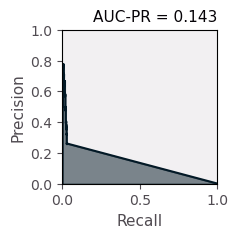

In [58]:
# plot the precision recall curve
bin_stats.plot_precision_recall_curve()

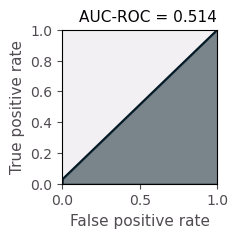

In [59]:
# plot the ROC curve
bin_stats.plot_roc_curve()

The computations and plots generated above, use the cutoff provided at the instatiation of the NetworkInferenceStats class.

If you want to change the cutoff value, you can do so by changing the cutoff attribute of the class and then calling the plot functions again.

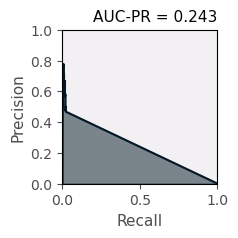

In [61]:
bin_stats.cutoff = 400
bin_stats.plot_precision_recall_curve()

You can also indicate the cutoff value when calling the method for a specific application:

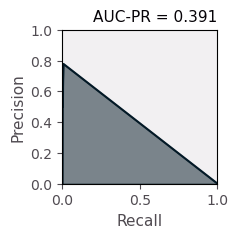

In [62]:
bin_stats.plot_precision_recall_curve(cutoff=100)

This won't change the associated cutoff value

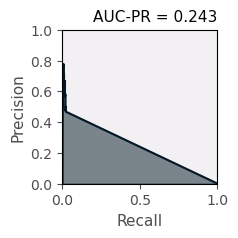

In [63]:
bin_stats.plot_precision_recall_curve()

In [64]:
self_loops = 8
directed = 4
giant_component = 2
paths = 1

In [70]:
mask = self_loops | directed | giant_component
mask == 0b1110

True

In [83]:
import numpy as np
foo = np.packbits([1, 1, 1, 0]) >> 4
if foo == mask:
    print("yes")

yes


In [85]:
from freyrelab.regnets.regnet import RegNet

In [87]:
import networkx as nx
G = nx.erdos_renyi_graph(100, 0.15, directed=True)
G = RegNet(G)

In [90]:
G.edges, G.number_of_edges()

(OutEdgeView([(0, 11), (0, 22), (0, 26), (0, 28), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 49), (0, 55), (0, 63), (0, 72), (0, 73), (0, 77), (0, 86), (0, 90), (0, 97), (1, 2), (1, 7), (1, 14), (1, 19), (1, 22), (1, 24), (1, 28), (1, 29), (1, 30), (1, 46), (1, 49), (1, 55), (1, 59), (1, 61), (1, 71), (1, 83), (2, 6), (2, 34), (2, 43), (2, 50), (2, 51), (2, 55), (2, 58), (2, 64), (2, 67), (2, 69), (2, 82), (2, 92), (3, 15), (3, 16), (3, 19), (3, 21), (3, 26), (3, 27), (3, 34), (3, 46), (3, 51), (3, 58), (3, 72), (3, 75), (3, 78), (3, 81), (3, 82), (3, 89), (3, 90), (4, 17), (4, 32), (4, 33), (4, 34), (4, 45), (4, 47), (4, 49), (4, 54), (4, 60), (4, 64), (4, 75), (4, 78), (4, 79), (4, 93), (4, 97), (5, 1), (5, 2), (5, 9), (5, 14), (5, 17), (5, 18), (5, 21), (5, 31), (5, 35), (5, 37), (5, 38), (5, 40), (5, 41), (5, 46), (5, 58), (5, 60), (5, 61), (5, 69), (5, 71), (5, 72), (5, 75), (5, 76), (5, 82), (5, 85), (5, 87), (5, 90), (5, 97), (6, 5), (6, 22), (6, 25), (6, 44), (6, 49), (6,

In [91]:
G.add_edge('A', 'B')

In [92]:
G.number_of_edges()

1525

In [94]:
G.giant_component

In [ ]:
directed = 8
self_loops = 4
giant_component = 2
paths = 1

modify_graph = {
      giant_component : self.G.giant_component(),
      self_loops: remove_self_loops(self.G),
    }

In [95]:
0b0100 | 0b0010

6

In [103]:
desired = 0b1000
estado_g_actual = 0b1100
estado_g_actual ^ desired

4

In [104]:
0b1111

15


010